### Baseline_Model

In [1]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("datasets/final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_22436\3849337911.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("datasets/final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [2]:
stints_clean = pd.read_csv('datasets/stints_clean.csv')
stints_clean.head(5)

,GP,Driver,Stint,Compound,StintLength
0,Australian Grand Prix,ALB,1,MEDIUM,6
1,Australian Grand Prix,ALO,1,MEDIUM,8
2,Australian Grand Prix,ALO,2,HARD,46
3,Australian Grand Prix,BOT,1,SOFT,1
4,Australian Grand Prix,BOT,2,HARD,6


In [3]:
model_df = stints_clean[
    (stints_clean['GP'] != 'Qatar Grand Prix') & 
    (stints_clean['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))
].copy()
model_df.head(5)

,GP,Driver,Stint,Compound,StintLength
0,Australian Grand Prix,ALB,1,MEDIUM,6
1,Australian Grand Prix,ALO,1,MEDIUM,8
2,Australian Grand Prix,ALO,2,HARD,46
3,Australian Grand Prix,BOT,1,SOFT,1
4,Australian Grand Prix,BOT,2,HARD,6


In [4]:
# Checking for NaN values in the target variable
model_df['StintLength'].isna().any()

False

In [9]:
#Defining features and target variable
X = model_df[['GP', 'Compound', 'Stint', 'GP_Stint', 'Compound_Stint']]
y = model_df['StintLength']

# model_df['Stint'].value_counts().sort_index()

#### Pipeline 

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge

categorial_features = ['GP', 'Compound', 'Stint', 'GP_Stint', 'Compound_Stint']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorial_features)
])

model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', Ridge(alpha=1.0))
    
])

In [8]:
model_df['GP_Stint'] = model_df['GP'] + '_S' + model_df['Stint'].astype(str)
model_df['Compound_Stint'] = model_df['Compound'] + '_S' + model_df['Stint'].astype(str)

model_df[['GP', 'Stint', 'GP_Stint']].head()

,GP,Stint,GP_Stint
0,Australian Grand Prix,1,Australian Grand Prix_S1
1,Australian Grand Prix,1,Australian Grand Prix_S1
2,Australian Grand Prix,2,Australian Grand Prix_S2
3,Australian Grand Prix,1,Australian Grand Prix_S1
4,Australian Grand Prix,2,Australian Grand Prix_S2


In [10]:
#splitting into train/test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
mae_v2 = mean_absolute_error(y_test, preds)
print('MAE:', mae_v2)

MAE: 5.952710126579771


In [ ]:
model.named_steps['preprocess'].get_feature_names_out()

array(['cat__GP_Australian Grand Prix', 'cat__GP_Austrian Grand Prix',
       'cat__GP_Azerbaijan Grand Prix', 'cat__GP_Bahrain Grand Prix',
       'cat__GP_Belgian Grand Prix', 'cat__GP_British Grand Prix',
       'cat__GP_Canadian Grand Prix', 'cat__GP_Dutch Grand Prix',
       'cat__GP_Hungarian Grand Prix', 'cat__GP_Italian Grand Prix',
       'cat__GP_Japanese Grand Prix', 'cat__GP_Las Vegas Grand Prix',
       'cat__GP_Mexico City Grand Prix', 'cat__GP_Miami Grand Prix',
       'cat__GP_Monaco Grand Prix', 'cat__GP_Saudi Arabian Grand Prix',
       'cat__GP_Singapore Grand Prix', 'cat__GP_Spanish Grand Prix',
       'cat__GP_São Paulo Grand Prix', 'cat__GP_United States Grand Prix',
       'cat__Compound_HARD', 'cat__Compound_MEDIUM', 'cat__Compound_SOFT',
       'cat__Stint_1', 'cat__Stint_2', 'cat__Stint_3', 'cat__Stint_4',
       'cat__Stint_5', 'cat__Stint_6', 'cat__Stint_7'], dtype=object)

In [12]:
import numpy as np

feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients
}).sort_values(by='coef', key=abs, ascending=False)

coef_df.head(15)

,feature,coef
85,cat__GP_Stint_Monaco Grand Prix_S1,14.938139
30,cat__GP_Stint_Australian Grand Prix_S1,-11.296412
35,cat__GP_Stint_Austrian Grand Prix_S1,-10.799432
86,cat__GP_Stint_Monaco Grand Prix_S2,-9.930707
53,cat__GP_Stint_British Grand Prix_S1,7.745656
41,cat__GP_Stint_Azerbaijan Grand Prix_S2,7.667099
60,cat__GP_Stint_Dutch Grand Prix_S1,-7.577347
78,cat__GP_Stint_Mexico City Grand Prix_S1,-7.398688
38,cat__GP_Stint_Austrian Grand Prix_S4,6.898165
43,cat__GP_Stint_Bahrain Grand Prix_S1,6.889484


In [ ]:
results = X_test.copy()
results['Actual Stint Length'] = y_test
results['Predicted Stint Length'] = preds
results['Error'] = abs(results['Actual Stint Length'] - results['Predicted Stint Length'])

results.groupby('GP')['Error'].mean().sort_values(ascending=False)

GP
Monaco Grand Prix           17.611998
Australian Grand Prix       15.658033
Dutch Grand Prix            10.129046
British Grand Prix           9.004604
Azerbaijan Grand Prix        8.702120
Japanese Grand Prix          8.192758
Bahrain Grand Prix           7.448216
Canadian Grand Prix          6.206274
Austrian Grand Prix          5.977583
Saudi Arabian Grand Prix     5.917892
Italian Grand Prix           5.886665
Miami Grand Prix             5.789034
Spanish Grand Prix           5.535650
Mexico City Grand Prix       5.508959
Singapore Grand Prix         5.084578
United States Grand Prix     4.961786
Hungarian Grand Prix         4.722042
Las Vegas Grand Prix         4.161447
Belgian Grand Prix           3.660958
São Paulo Grand Prix         2.982121
Name: Error, dtype: float64

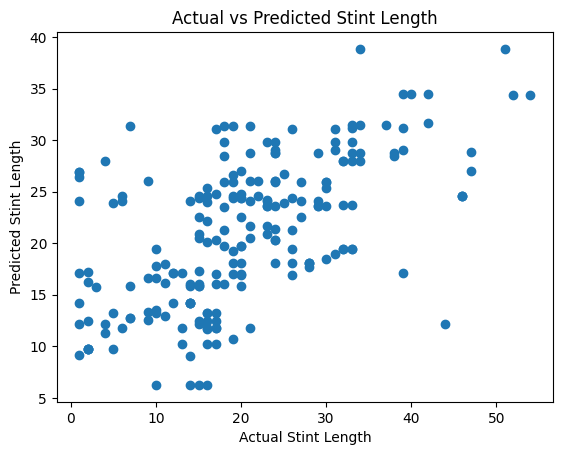

In [ ]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()

In [13]:
# Visualizing Error by GP
gp_error = results.groupby('GP')['Error'].mean().sort_values()

plt.figure()

gp_error.plot(kind='barh')

plt.xlabel("Mean Absolute Error (laps)")
plt.title("Error by GP")
plt.ylabel("GP")

plt.show()

NameError: name 'results' is not defined

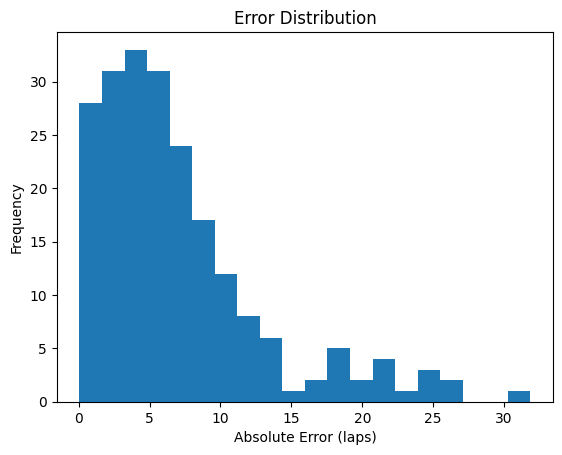

In [ ]:
plt.figure()

plt.hist(results['Error'], bins=20)

plt.xlabel("Absolute Error (laps)")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

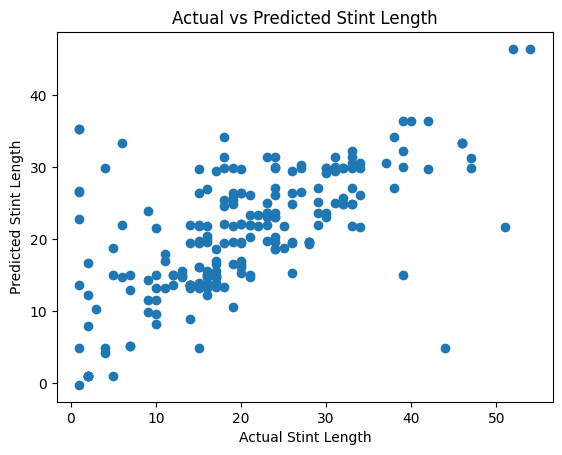

In [14]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()

In [ ]:
import numpy as np

feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients
}).sort_values(by='coef', key=abs, ascending=False)

coef_df.head(15)

,feature,coef
85,cat__GP_Stint_Monaco Grand Prix_S1,14.938139
30,cat__GP_Stint_Australian Grand Prix_S1,-11.296412
35,cat__GP_Stint_Austrian Grand Prix_S1,-10.799432
86,cat__GP_Stint_Monaco Grand Prix_S2,-9.930707
53,cat__GP_Stint_British Grand Prix_S1,7.745656
41,cat__GP_Stint_Azerbaijan Grand Prix_S2,7.667099
60,cat__GP_Stint_Dutch Grand Prix_S1,-7.577347
78,cat__GP_Stint_Mexico City Grand Prix_S1,-7.398688
38,cat__GP_Stint_Austrian Grand Prix_S4,6.898165
43,cat__GP_Stint_Bahrain Grand Prix_S1,6.889484


In [ ]:
model_df['GP_Stint'].value_counts().min()

1

In [18]:
alphas = [1.0]

In [28]:
from sklearn.metrics import mean_absolute_error
import pandas as pd

results = []

for alpha in alphas:
    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('regressor', Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    

    #coefficient magnitude
    coefs = model.named_steps['regressor'].coef_
    coef_magnitude = abs(coefs).mean()

    results.append({'alpha': alpha, 'MAE': mae, 'avg_coef_magnitude': coef_magnitude})

    results_df = pd.DataFrame(results)
    print(results_df)



   alpha      MAE  avg_coef_magnitude
0    1.0  5.95271            2.777591


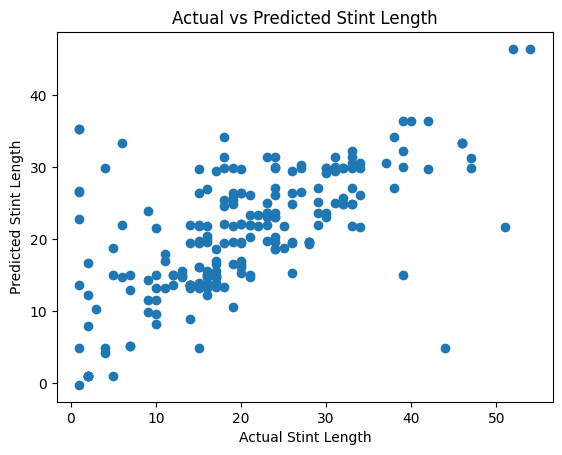

In [31]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()

In [2]:
df_2023.columns

Index(['Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound', 'TyreLife',
       'FreshTyre', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Team', 'Position', 'DriverTime', 'WeatherTime', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
       'RoundNumber', 'Session', 'Date', 'GP'],
      dtype='object')

In [3]:
session = fastf1.get_session(2023, 'Monaco', 'R')
session.load()


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']


In [4]:
track_status = session.track_status

In [22]:
def predict_stint_length(gp, compound, stint):
    gp_stint = f"{gp}_S{stint}"
    compound_stint = f"{compound}_S{stint}"
    
    input_data = pd.DataFrame({
        'GP': [gp],
        'Compound': [compound],
        'Stint': [stint],
        'GP_Stint': [gp_stint],
        'Compound_Stint': [compound_stint]
    })
    
    predicted_length = model.predict(input_data)[0]
    return (predicted_length)

In [23]:
predict_stint_length(
    gp='Monaco Grand Prix', 
    compound='MEDIUM',
    stint=1
)

35.26514350123824

In [28]:
predict_stint_length(
    gp='Monaco Grand Prix', 
    compound='SOFT', 
    stint=2
)

14.807290377978388

In [29]:
model_df[
    (model_df['GP'] == "Monaco Grand Prix") &
    (model_df['Compound'] == "MEDIUM") &
    (model_df['Stint'] == 1)
]

,GP,Driver,Stint,Compound,StintLength,GP_Stint,Compound_Stint
814,Monaco Grand Prix,ALB,1,MEDIUM,18,Monaco Grand Prix_S1,MEDIUM_S1
822,Monaco Grand Prix,DEV,1,MEDIUM,53,Monaco Grand Prix_S1,MEDIUM_S1
827,Monaco Grand Prix,HAM,1,MEDIUM,31,Monaco Grand Prix_S1,MEDIUM_S1
830,Monaco Grand Prix,HUL,1,MEDIUM,1,Monaco Grand Prix_S1,MEDIUM_S1
839,Monaco Grand Prix,NOR,1,MEDIUM,50,Monaco Grand Prix_S1,MEDIUM_S1
842,Monaco Grand Prix,OCO,1,MEDIUM,32,Monaco Grand Prix_S1,MEDIUM_S1
845,Monaco Grand Prix,PER,1,MEDIUM,1,Monaco Grand Prix_S1,MEDIUM_S1
858,Monaco Grand Prix,SAR,1,MEDIUM,20,Monaco Grand Prix_S1,MEDIUM_S1
864,Monaco Grand Prix,TSU,1,MEDIUM,53,Monaco Grand Prix_S1,MEDIUM_S1
866,Monaco Grand Prix,VER,1,MEDIUM,55,Monaco Grand Prix_S1,MEDIUM_S1


In [30]:
predict_stint_length('Monaco Grand Prix', 'HARD', 2)

21.659629079395724

In [63]:
model_df[
    (model_df['GP'] == "Monaco Grand Prix") &
    (model_df['Compound'] == "HARD") &
    (model_df['Stint'] == 2)
]


,GP,Driver,Stint,Compound,StintLength,GP_Stint,Compound_Stint
815,Monaco Grand Prix,ALB,2,HARD,34,Monaco Grand Prix_S2,HARD_S2
828,Monaco Grand Prix,HAM,2,HARD,23,Monaco Grand Prix_S2,HARD_S2
831,Monaco Grand Prix,HUL,2,HARD,52,Monaco Grand Prix_S2,HARD_S2
840,Monaco Grand Prix,NOR,2,HARD,4,Monaco Grand Prix_S2,HARD_S2
843,Monaco Grand Prix,OCO,2,HARD,22,Monaco Grand Prix_S2,HARD_S2
846,Monaco Grand Prix,PER,2,HARD,33,Monaco Grand Prix_S2,HARD_S2
859,Monaco Grand Prix,SAR,2,HARD,3,Monaco Grand Prix_S2,HARD_S2
869,Monaco Grand Prix,ZHO,2,HARD,51,Monaco Grand Prix_S2,HARD_S2


In [15]:
model_df[
    (model_df['GP'] == 'Monaco Grand Prix') &
    (model_df['Compound_Stint'] == 'HARD_S1')
]['StintLength'].mean()

49.44444444444444

In [58]:
predict_stint_length("Monaco Grand Prix", "SOFT", 1)
# # predict_stint_length("Monaco Grand Prix", "MEDIUM", 1)
# predict_stint_length("Monaco Grand Prix", "HARD", 1)


29.85864201135976

In [40]:
model_df['GP'].unique()

array(['Australian Grand Prix', 'Austrian Grand Prix',
       'Azerbaijan Grand Prix', 'Bahrain Grand Prix',
       'Belgian Grand Prix', 'British Grand Prix', 'Canadian Grand Prix',
       'Dutch Grand Prix', 'Hungarian Grand Prix', 'Italian Grand Prix',
       'Japanese Grand Prix', 'Las Vegas Grand Prix',
       'Mexico City Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix',
       'Saudi Arabian Grand Prix', 'Singapore Grand Prix',
       'Spanish Grand Prix', 'São Paulo Grand Prix',
       'United States Grand Prix'], dtype=object)

In [46]:
predict_stint_length('British Grand Prix', 'MEDIUM', 1)

24.935375343007497

In [45]:
model_df[
    (model_df['GP'] == "British Grand Prix") &
    (model_df['Compound'] == "MEDIUM") &
    (model_df['Stint'] == 1)
]


,GP,Driver,Stint,Compound,StintLength,GP_Stint,Compound_Stint
298,British Grand Prix,ALB,1,MEDIUM,32,British Grand Prix_S1,MEDIUM_S1
300,British Grand Prix,ALO,1,MEDIUM,34,British Grand Prix_S1,MEDIUM_S1
307,British Grand Prix,GAS,1,MEDIUM,31,British Grand Prix_S1,MEDIUM_S1
309,British Grand Prix,HAM,1,MEDIUM,33,British Grand Prix_S1,MEDIUM_S1
314,British Grand Prix,LEC,1,MEDIUM,18,British Grand Prix_S1,MEDIUM_S1
317,British Grand Prix,MAG,1,MEDIUM,31,British Grand Prix_S1,MEDIUM_S1
318,British Grand Prix,NOR,1,MEDIUM,33,British Grand Prix_S1,MEDIUM_S1
321,British Grand Prix,PER,1,MEDIUM,28,British Grand Prix_S1,MEDIUM_S1
323,British Grand Prix,PIA,1,MEDIUM,29,British Grand Prix_S1,MEDIUM_S1
327,British Grand Prix,SAI,1,MEDIUM,26,British Grand Prix_S1,MEDIUM_S1


In [47]:
model_df[
    (model_df['GP'] == 'British Grand Prix') &
    (model_df['Compound_Stint'] == 'MEDIUM_S1')
]['StintLength'].mean()

29.5

#### Loop for model_testing

In [54]:
gps = model_df['GP'].unique()
compounds = model_df['Compound'].unique()
stints = [1,2,3]



In [55]:
results = []
for gp in gps:
    for compound in compounds:
        for stint in stints:
            subset = model_df[
                (model_df['GP'] == gp) & 
                (model_df['Compound'] == compound) &
                (model_df['Stint'] == stint)
]
            if len(subset) == 0:    
                continue

            acutal_mean = subset['StintLength'].mean()
            pred = predict_stint_length(gp, compound, stint)

            results.append({
                'GP' : gp,
                'Compound': compound,
                'Stint': stint,
                'Acutal Mean': acutal_mean,
                'Predicted': pred,
                'Error': abs(acutal_mean - pred)
})

In [57]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='Error', ascending=False).head(10)

,GP,Compound,Stint,Acutal Mean,Predicted,Error
94,Monaco Grand Prix,SOFT,1,1.0,29.858642,28.858642
17,Azerbaijan Grand Prix,SOFT,2,1.0,27.327049,26.327049
47,Canadian Grand Prix,SOFT,3,2.0,21.641030,19.641030
35,British Grand Prix,HARD,1,19.5,36.111819,16.611819
112,Spanish Grand Prix,HARD,1,16.0,31.591093,15.591093
19,Bahrain Grand Prix,HARD,1,15.0,29.792064,14.792064
1,Australian Grand Prix,MEDIUM,2,13.0,26.695805,13.695805
2,Australian Grand Prix,HARD,1,3.0,16.360409,13.360409
14,Azerbaijan Grand Prix,HARD,1,36.0,22.791384,13.208616
6,Australian Grand Prix,SOFT,3,8.0,20.821211,12.821211


## Strategy Simulation Engine

In [16]:
# These are the official 2023 race lap counts.
# Used to enforce the lap budget constraint during simulation.
 
RACE_LAPS = {
    'Bahrain Grand Prix': 57,
    'Saudi Arabian Grand Prix': 50,
    'Australian Grand Prix': 58,
    'Azerbaijan Grand Prix': 51,
    'Miami Grand Prix': 57,
    'Monaco Grand Prix': 78,
    'Spanish Grand Prix': 66,
    'Canadian Grand Prix': 70,
    'Austrian Grand Prix': 71,
    'British Grand Prix': 52,
    'Hungarian Grand Prix': 70,
    'Belgian Grand Prix': 44,
    'Dutch Grand Prix': 72,
    'Italian Grand Prix': 51,
    'Singapore Grand Prix': 62,
    'Japanese Grand Prix': 53,
    'Qatar Grand Prix': 57,
    'United States Grand Prix': 56,
    'Mexico City Grand Prix': 71,
    'São Paulo Grand Prix': 71,
    'Las Vegas Grand Prix': 50,
    'Abu Dhabi Grand Prix': 58,
}


In [17]:
# Generates all valid compound sequences for 1-stop and 2-stop strategies.
# F1 rule: must use at least 2 different compounds.
 
from itertools import product
 
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
 
def get_valid_strategies(n_stops=1):
    """
    Returns a list of compound sequences for the given number of stops.
    Each sequence is a list of compounds, one per stint.
    
    n_stops=1 → 2 stints, n_stops=2 → 3 stints
    
    Enforces the F1 rule: at least 2 distinct compounds must be used.
    """
    n_stints = n_stops + 1
    all_sequences = list(product(COMPOUNDS, repeat=n_stints))
    
    # Filter: must use at least 2 different compounds
    valid = [seq for seq in all_sequences if len(set(seq)) >= 2]
    return valid
 
 
# Preview
print("1-stop strategies:", len(get_valid_strategies(1)))
print("2-stop strategies:", len(get_valid_strategies(2)))
print()
print("Sample 1-stop strategies:")
for s in get_valid_strategies(1):
    print(" →", " → ".join(s))

1-stop strategies: 6
2-stop strategies: 24

Sample 1-stop strategies:
 → SOFT → MEDIUM
 → SOFT → HARD
 → MEDIUM → SOFT
 → MEDIUM → HARD
 → HARD → SOFT
 → HARD → MEDIUM


In [24]:
# Simulates a single compound sequence for a given GP.
# Predicts each stint sequentially and enforces the lap budget.
 
def simulate_strategy(gp, compound_sequence, total_laps):
    """
    Simulates a full race strategy for a given GP and compound sequence.
    
    Parameters:
        gp (str): Grand Prix name (must match model training data)
        compound_sequence (list): e.g. ['MEDIUM', 'HARD'] for a 1-stop
        total_laps (int): Total race laps for the GP
    
    Returns:
        dict with stint breakdown, predicted laps per stint, and validity flag
    """
    stints = []
    laps_used = 0
 
    for i, compound in enumerate(compound_sequence):
        stint_number = i + 1
        remaining_laps = total_laps - laps_used
        is_last_stint = (i == len(compound_sequence) - 1)
 
        if is_last_stint:
            # Final stint absorbs whatever laps remain
            predicted = remaining_laps
        else:
            predicted = predict_stint_length(gp, compound, stint_number)
            # Clamp: can't predict more than laps remaining (leave at least 1 lap for last stint)
            predicted = min(predicted, remaining_laps - (len(compound_sequence) - stint_number))
            predicted = max(predicted, 1)  # must be at least 1 lap
 
        laps_used += predicted
 
        stints.append({
            'Stint': stint_number,
            'Compound': compound,
            'PredictedLaps': round(predicted, 1),
        })
 
    total_predicted = sum(s['PredictedLaps'] for s in stints)
    budget_ok = abs(total_predicted - total_laps) <= 0.5  # within rounding
 
    return {
        'GP': gp,
        'Strategy': ' → '.join(compound_sequence),
        'Stints': stints,
        'TotalPredictedLaps': round(total_predicted, 1),
        'RaceLaps': total_laps,
        'BudgetValid': budget_ok
    }
 

In [25]:
simulate_strategy('Monaco Grand Prix', ['MEDIUM', 'HARD'], 78)

{'GP': 'Monaco Grand Prix',
 'Strategy': 'MEDIUM → HARD',
 'Stints': [{'Stint': 1, 'Compound': 'MEDIUM', 'PredictedLaps': 35.3},
  {'Stint': 2, 'Compound': 'HARD', 'PredictedLaps': 42.7}],
 'TotalPredictedLaps': 78.0,
 'RaceLaps': 78,
 'BudgetValid': True}

In [26]:
# Runs all valid strategies for a given GP and returns a comparison DataFrame.
 
def compare_strategies(gp, n_stops_list=[1, 2]):
    """
    Compares all valid strategies for a given GP across 1-stop and 2-stop.
    
    Returns a DataFrame with one row per strategy, sorted by
    how evenly the laps are distributed across stints (proxy for feasibility).
    """
    total_laps = RACE_LAPS.get(gp)
    if total_laps is None:
        raise ValueError(f"GP '{gp}' not found in RACE_LAPS. Check spelling.")
 
    rows = []
 
    for n_stops in n_stops_list:
        sequences = get_valid_strategies(n_stops)
        for seq in sequences:
            result = simulate_strategy(gp, seq, total_laps)
 
            # Compute stint balance: std dev of predicted stint lengths
            # Lower = more evenly distributed race (generally preferred strategically)
            stint_lengths = [s['PredictedLaps'] for s in result['Stints']]
            import numpy as np
            balance_score = round(np.std(stint_lengths), 2)
 
            stint_detail = ' | '.join(
                f"S{s['Stint']} {s['Compound']} ({s['PredictedLaps']} laps)"
                for s in result['Stints']
            )
 
            rows.append({
                'Strategy': result['Strategy'],
                'Stops': n_stops,
                'StintDetail': stint_detail,
                'TotalLaps': result['TotalPredictedLaps'],
                'BalanceScore': balance_score,  # lower = more even
            })
 
    df = pd.DataFrame(rows).sort_values(by='BalanceScore')
    return df
 

In [28]:
compare_strategies('Monaco Grand Prix')

,Strategy,Stops,StintDetail,TotalLaps,BalanceScore
13,SOFT → HARD → HARD,2,S1 SOFT (29.9 laps) | S2 HARD (21.7 laps) | S3...,78.1,3.36
12,SOFT → HARD → MEDIUM,2,S1 SOFT (29.9 laps) | S2 HARD (21.7 laps) | S3...,78.1,3.36
11,SOFT → HARD → SOFT,2,S1 SOFT (29.9 laps) | S2 HARD (21.7 laps) | S3...,78.1,3.36
2,MEDIUM → SOFT,1,S1 MEDIUM (35.3 laps) | S2 SOFT (42.7 laps),78.0,3.70
3,MEDIUM → HARD,1,S1 MEDIUM (35.3 laps) | S2 HARD (42.7 laps),78.0,3.70
19,MEDIUM → HARD → SOFT,2,S1 MEDIUM (35.3 laps) | S2 HARD (21.7 laps) | ...,78.1,6.56
21,MEDIUM → HARD → HARD,2,S1 MEDIUM (35.3 laps) | S2 HARD (21.7 laps) | ...,78.1,6.56
20,MEDIUM → HARD → MEDIUM,2,S1 MEDIUM (35.3 laps) | S2 HARD (21.7 laps) | ...,78.1,6.56
4,HARD → SOFT,1,S1 HARD (46.4 laps) | S2 SOFT (31.6 laps),78.0,7.40
5,HARD → MEDIUM,1,S1 HARD (46.4 laps) | S2 MEDIUM (31.6 laps),78.0,7.40


In [29]:
# Run the comparison for a specific GP ───────────────────────────
 
gp_to_simulate = 'British Grand Prix'   # ← change this to any GP
 
comparison = compare_strategies(gp_to_simulate, n_stops_list=[1, 2])
 
print(f"\n{'='*60}")
print(f"  Strategy Comparison — {gp_to_simulate}")
print(f"  Race distance: {RACE_LAPS[gp_to_simulate]} laps")
print(f"{'='*60}\n")
 
print(comparison[['Strategy', 'Stops', 'StintDetail', 'BalanceScore']].to_string(index=False))


  Strategy Comparison — British Grand Prix
  Race distance: 52 laps

              Strategy  Stops                                                         StintDetail  BalanceScore
         MEDIUM → SOFT      1                         S1 MEDIUM (24.9 laps) | S2 SOFT (27.1 laps)          1.10
         MEDIUM → HARD      1                         S1 MEDIUM (24.9 laps) | S2 HARD (27.1 laps)          1.10
  SOFT → SOFT → MEDIUM      2   S1 SOFT (19.5 laps) | S2 SOFT (18.6 laps) | S3 MEDIUM (13.9 laps)          2.46
    SOFT → SOFT → HARD      2     S1 SOFT (19.5 laps) | S2 SOFT (18.6 laps) | S3 HARD (13.9 laps)          2.46
  SOFT → MEDIUM → SOFT      2   S1 SOFT (19.5 laps) | S2 MEDIUM (18.8 laps) | S3 SOFT (13.7 laps)          2.58
SOFT → MEDIUM → MEDIUM      2 S1 SOFT (19.5 laps) | S2 MEDIUM (18.8 laps) | S3 MEDIUM (13.7 laps)          2.58
  SOFT → MEDIUM → HARD      2   S1 SOFT (19.5 laps) | S2 MEDIUM (18.8 laps) | S3 HARD (13.7 laps)          2.58
         SOFT → MEDIUM      1     

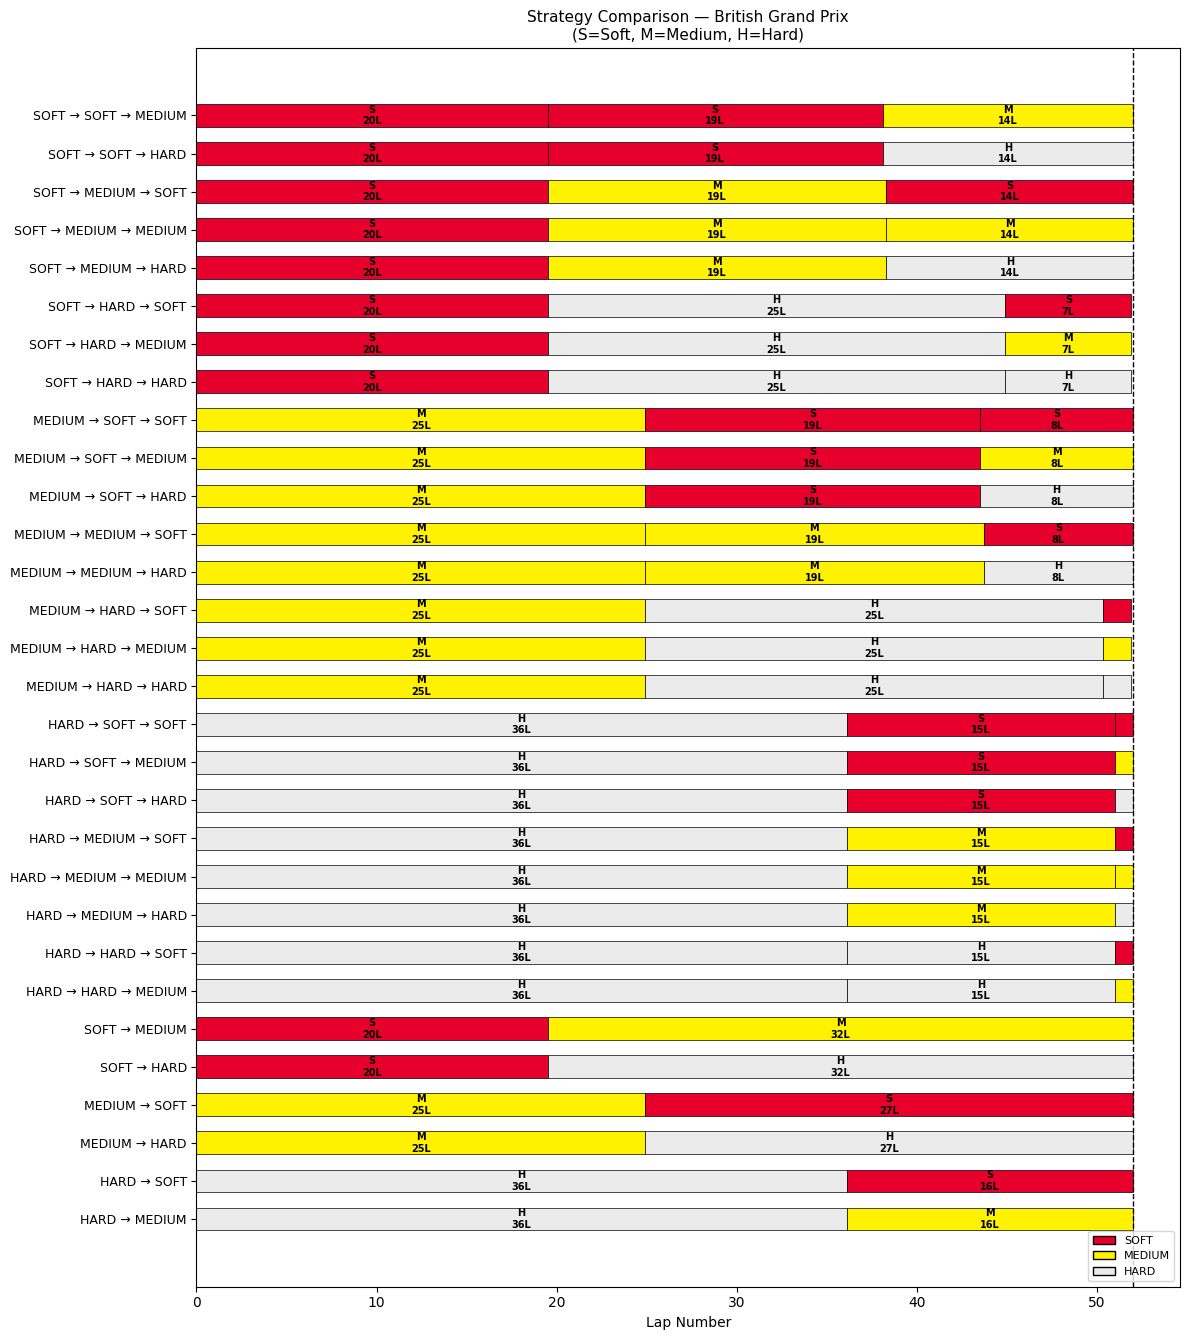

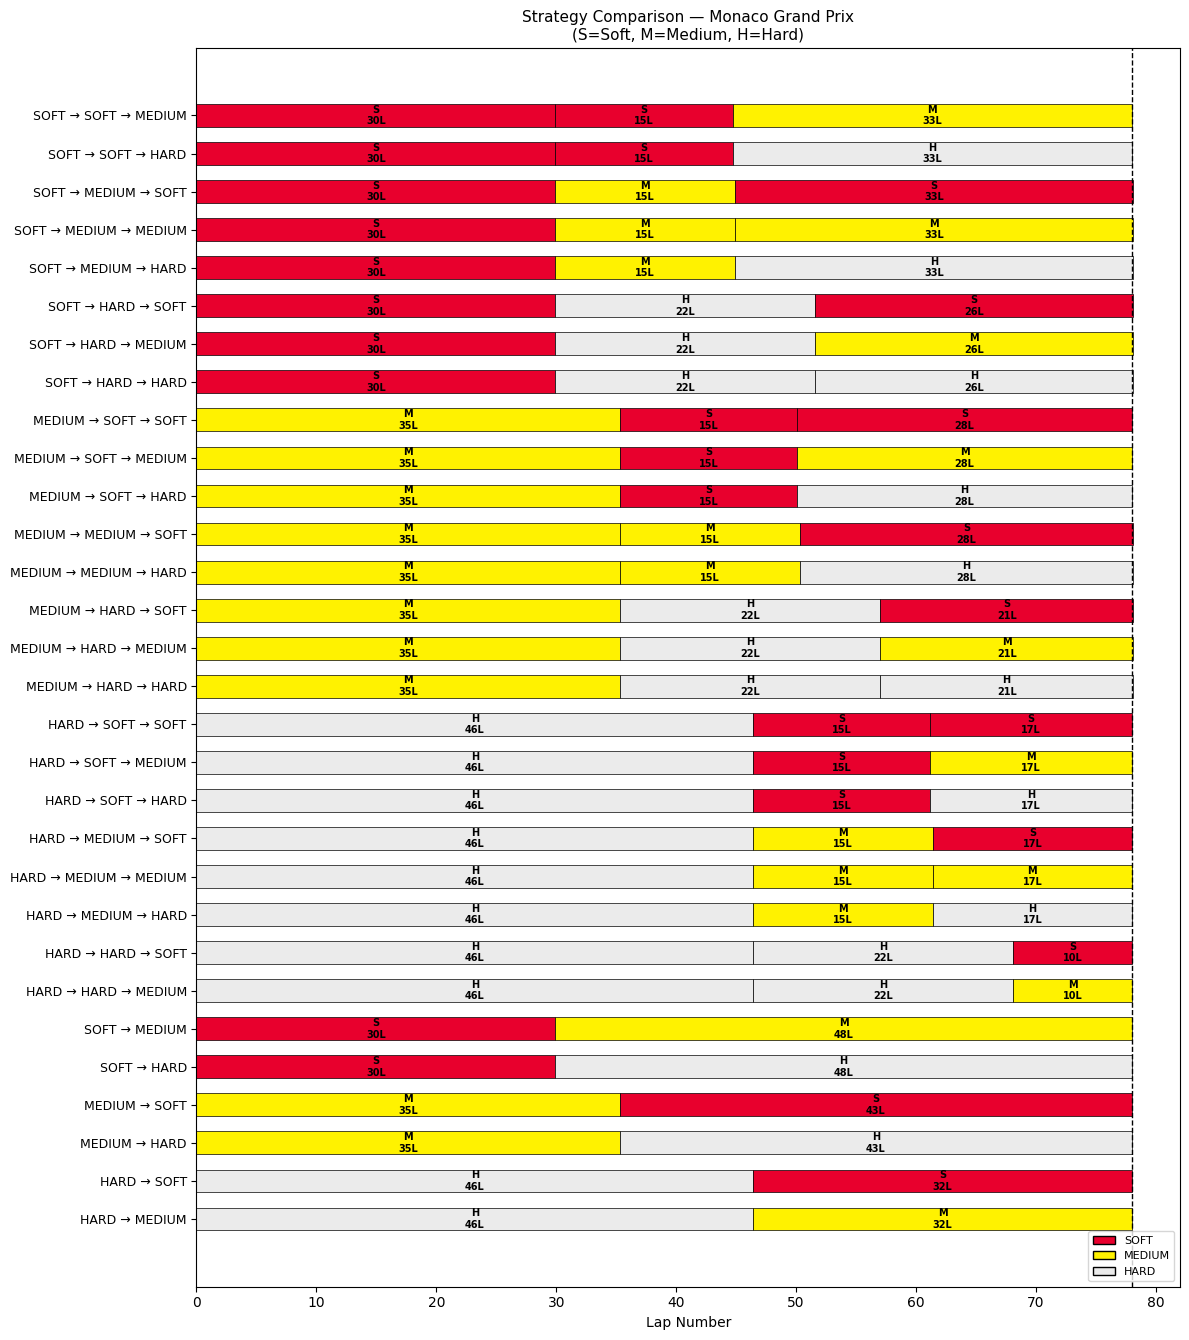

In [30]:
import matplotlib.pyplot as plt
import numpy as np
 
def plot_strategy_comparison(gp, n_stops_list=[1, 2]):
    total_laps = RACE_LAPS[gp]
    compound_colors = {'SOFT': '#E8002D', 'MEDIUM': '#FFF200', 'HARD': '#EBEBEB'}
 
    all_strategies = []
    for n_stops in n_stops_list:
        for seq in get_valid_strategies(n_stops):
            result = simulate_strategy(gp, seq, total_laps)
            all_strategies.append(result)
 
    # Sort by number of stops, then strategy name
    all_strategies.sort(key=lambda x: (len(x['Stints']), x['Strategy']))
 
    fig, ax = plt.subplots(figsize=(12, max(4, len(all_strategies) * 0.45)))
 
    for row_idx, strat in enumerate(all_strategies):
        lap_cursor = 0
        for stint in strat['Stints']:
            color = compound_colors.get(stint['Compound'], '#AAAAAA')
            bar = ax.barh(
                row_idx,
                stint['PredictedLaps'],
                left=lap_cursor,
                color=color,
                edgecolor='black',
                linewidth=0.5,
                height=0.6
            )
            # Label inside bar if wide enough
            if stint['PredictedLaps'] > 4:
                ax.text(
                    lap_cursor + stint['PredictedLaps'] / 2,
                    row_idx,
                    f"{stint['Compound'][0]}\n{stint['PredictedLaps']:.0f}L",
                    ha='center', va='center', fontsize=7, fontweight='bold'
                )
            lap_cursor += stint['PredictedLaps']
 
    ax.set_yticks(range(len(all_strategies)))
    ax.set_yticklabels([s['Strategy'] for s in all_strategies], fontsize=9)
    ax.set_xlabel('Lap Number')
    ax.set_title(f'Strategy Comparison — {gp}\n(S=Soft, M=Medium, H=Hard)', fontsize=11)
    ax.axvline(total_laps, color='black', linestyle='--', linewidth=1, label=f'Race end ({total_laps} laps)')
    ax.legend(fontsize=8)
 
    # Compound legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, edgecolor='black', label=k)
                       for k, v in compound_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
 
    plt.tight_layout()
    plt.show()
 
 
plot_strategy_comparison('British Grand Prix')
plot_strategy_comparison('Monaco Grand Prix')